# 내일 비가 올지 예측해보기 (Rain in Australia) 
- 랜덤 포레스트(Random Forest) 이용
- Outlier 제거로 성능 향상시켜 보기

### Outlier 제거
<img src="https://miro.medium.com/max/18000/1*2c21SkzJMf3frPXPAR_gZA.png">


# baseline 성능
7-1a Random_Forest로_내일_비가올지_예측해보기 (Rain in Australia).ipynb 
#### baseline - 랜덤 포레스트(Random Forest) 
#### accuracy : 0.86, precision : 0.87,  recall : 0.73, f1-score : 0.76

In [68]:
# 불필요한 경고 출력을 방지
import warnings
warnings.filterwarnings('ignore')

## 관련 라이브러리 import

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

# 데이터 로딩 

In [70]:
df = pd.read_csv('datas_ml/weatherAUS.csv')
print(df.shape)

(145460, 23)


# EDA 및 데이터 전처리

## 데이터 형상 파악하기

In [71]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [73]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


<Axes: xlabel='RainTomorrow', ylabel='count'>

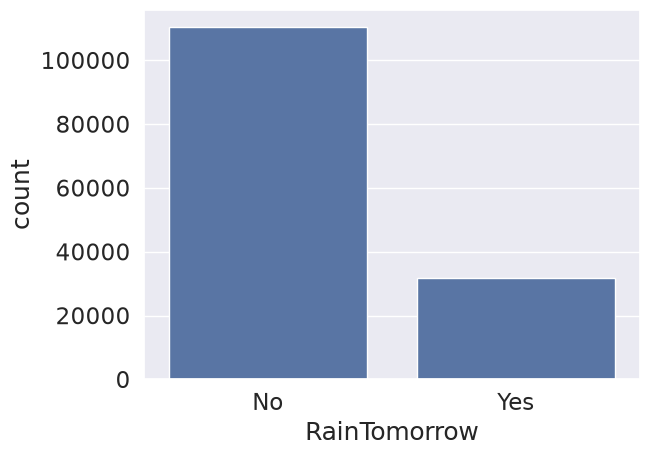

In [74]:
sns.countplot(x="RainTomorrow", data=df)

In [75]:
cat_cols = df.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')

In [76]:
print(cat_cols)
df[cat_cols].describe()

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,135134,134894,141232,142199,142193
unique,3436,49,16,16,16,2,2
top,2013-03-01,Canberra,W,N,SE,No,No
freq,49,3436,9915,11758,10838,110319,110316


## 상관 분석(Correlation Analysis) 수행해보기

In [77]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')

In [78]:
temp_df = df[num_cols]
temp_df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7


In [79]:
temp_df.shape

(145460, 16)

In [80]:
# Yes/No 값을 0, 1로 변경하기
temp_df['RainToday'] = df['RainToday'].replace({'No': 0, 'Yes': 1})
temp_df['RainTomorrow'] = df['RainTomorrow'].replace({'No': 0, 'Yes': 1})

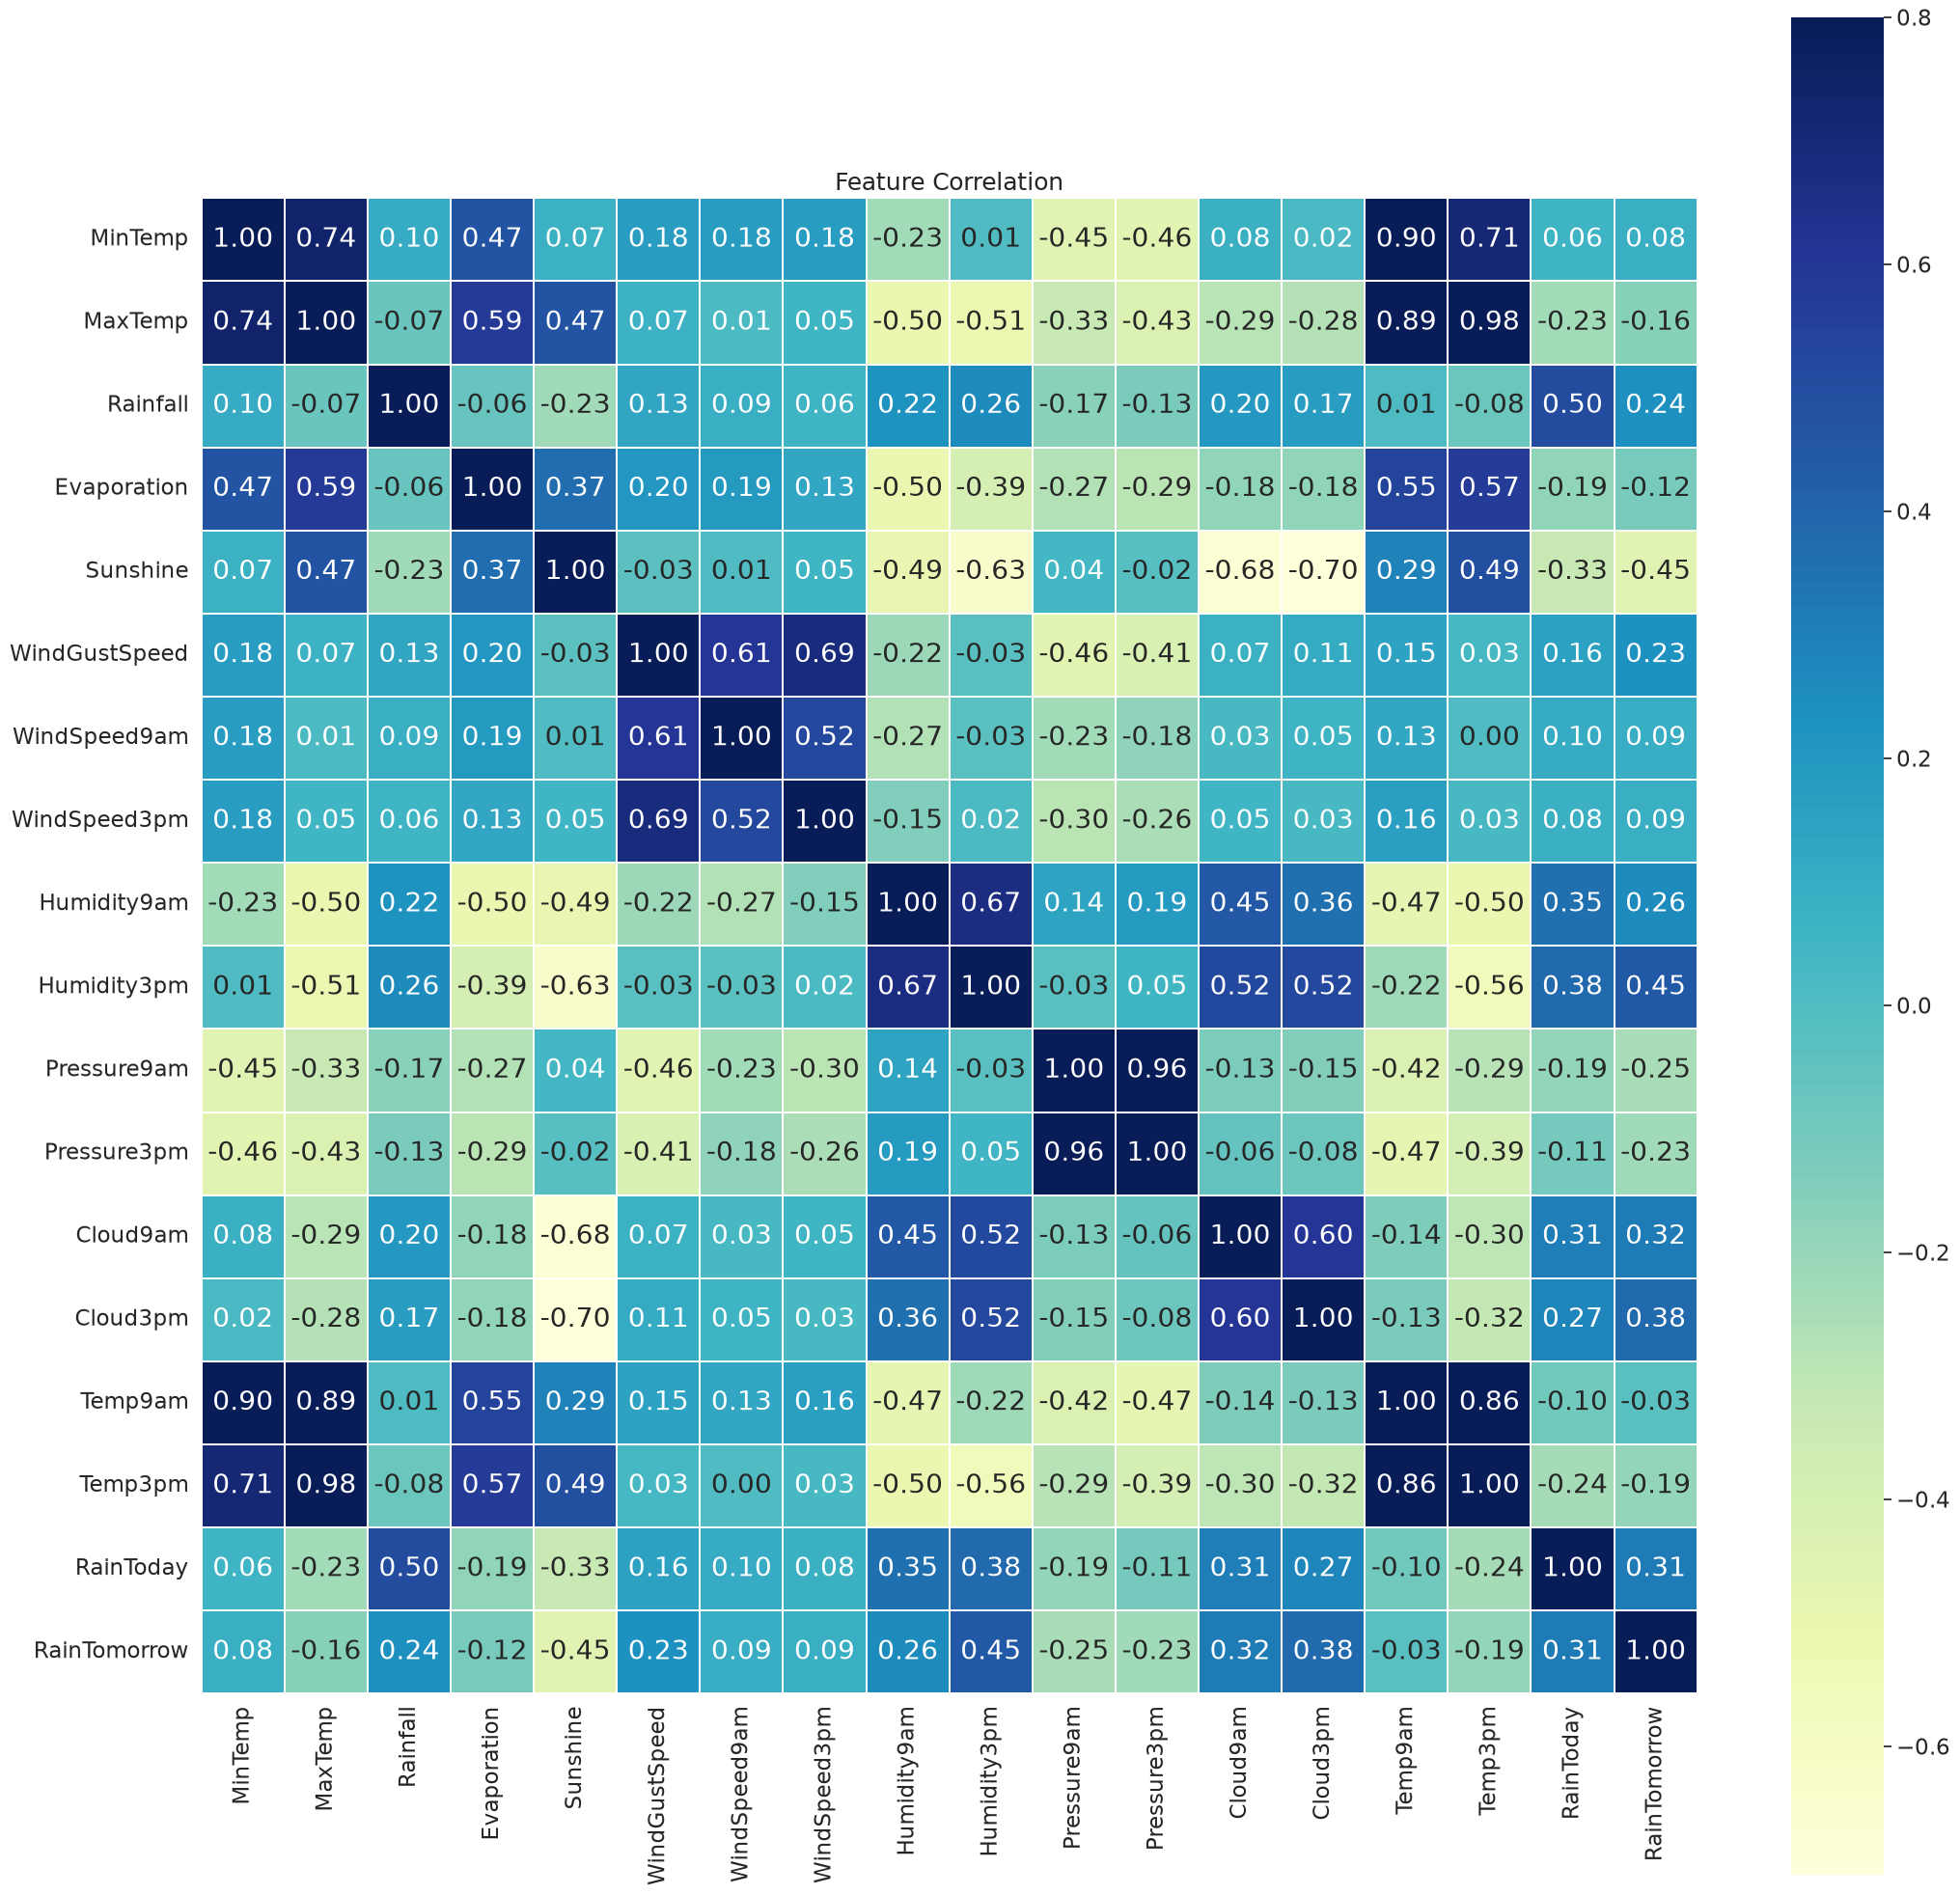

In [81]:
corr = temp_df.corr()
plt.figure(figsize=(25, 25));
sns.set(font_scale=1.5); # plot의 글자크기 설정
sns.heatmap(corr,
            vmax=0.8,
            linewidths=0.01,
            square=True,
            annot=True,
            fmt = '.2f', # annot의 출력 소숫점 자리 지정
            annot_kws={"size": 20},  # annot 글자크기
            cmap='YlGnBu');
plt.title('Feature Correlation');

In [82]:
corr.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')

In [83]:
# RainTomorrow와 상관관계가 있는 feature 살펴보기
# Rainfall,'Evaporation', Sunshine, WindGustSpeed','Humidity9am', ' 'Pressure9am', 
# 'Pressure3pm', Cloud9am, Cloud3pm

## Outlier 분석

<Axes: ylabel='Sunshine'>

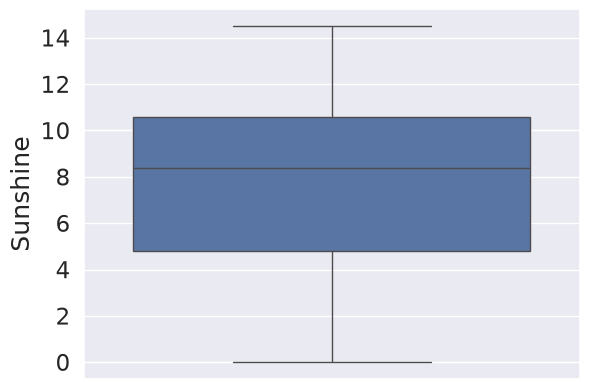

In [84]:
sns.boxplot(data=df, y='Sunshine')

In [85]:
df.shape

(145460, 23)

### categorical / numerical column 리스트 추출

In [86]:
print(cat_cols)

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


In [87]:
print(num_cols)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')


### [문제해결] 숫자형 컬럼을 boxplot()으로 시각화

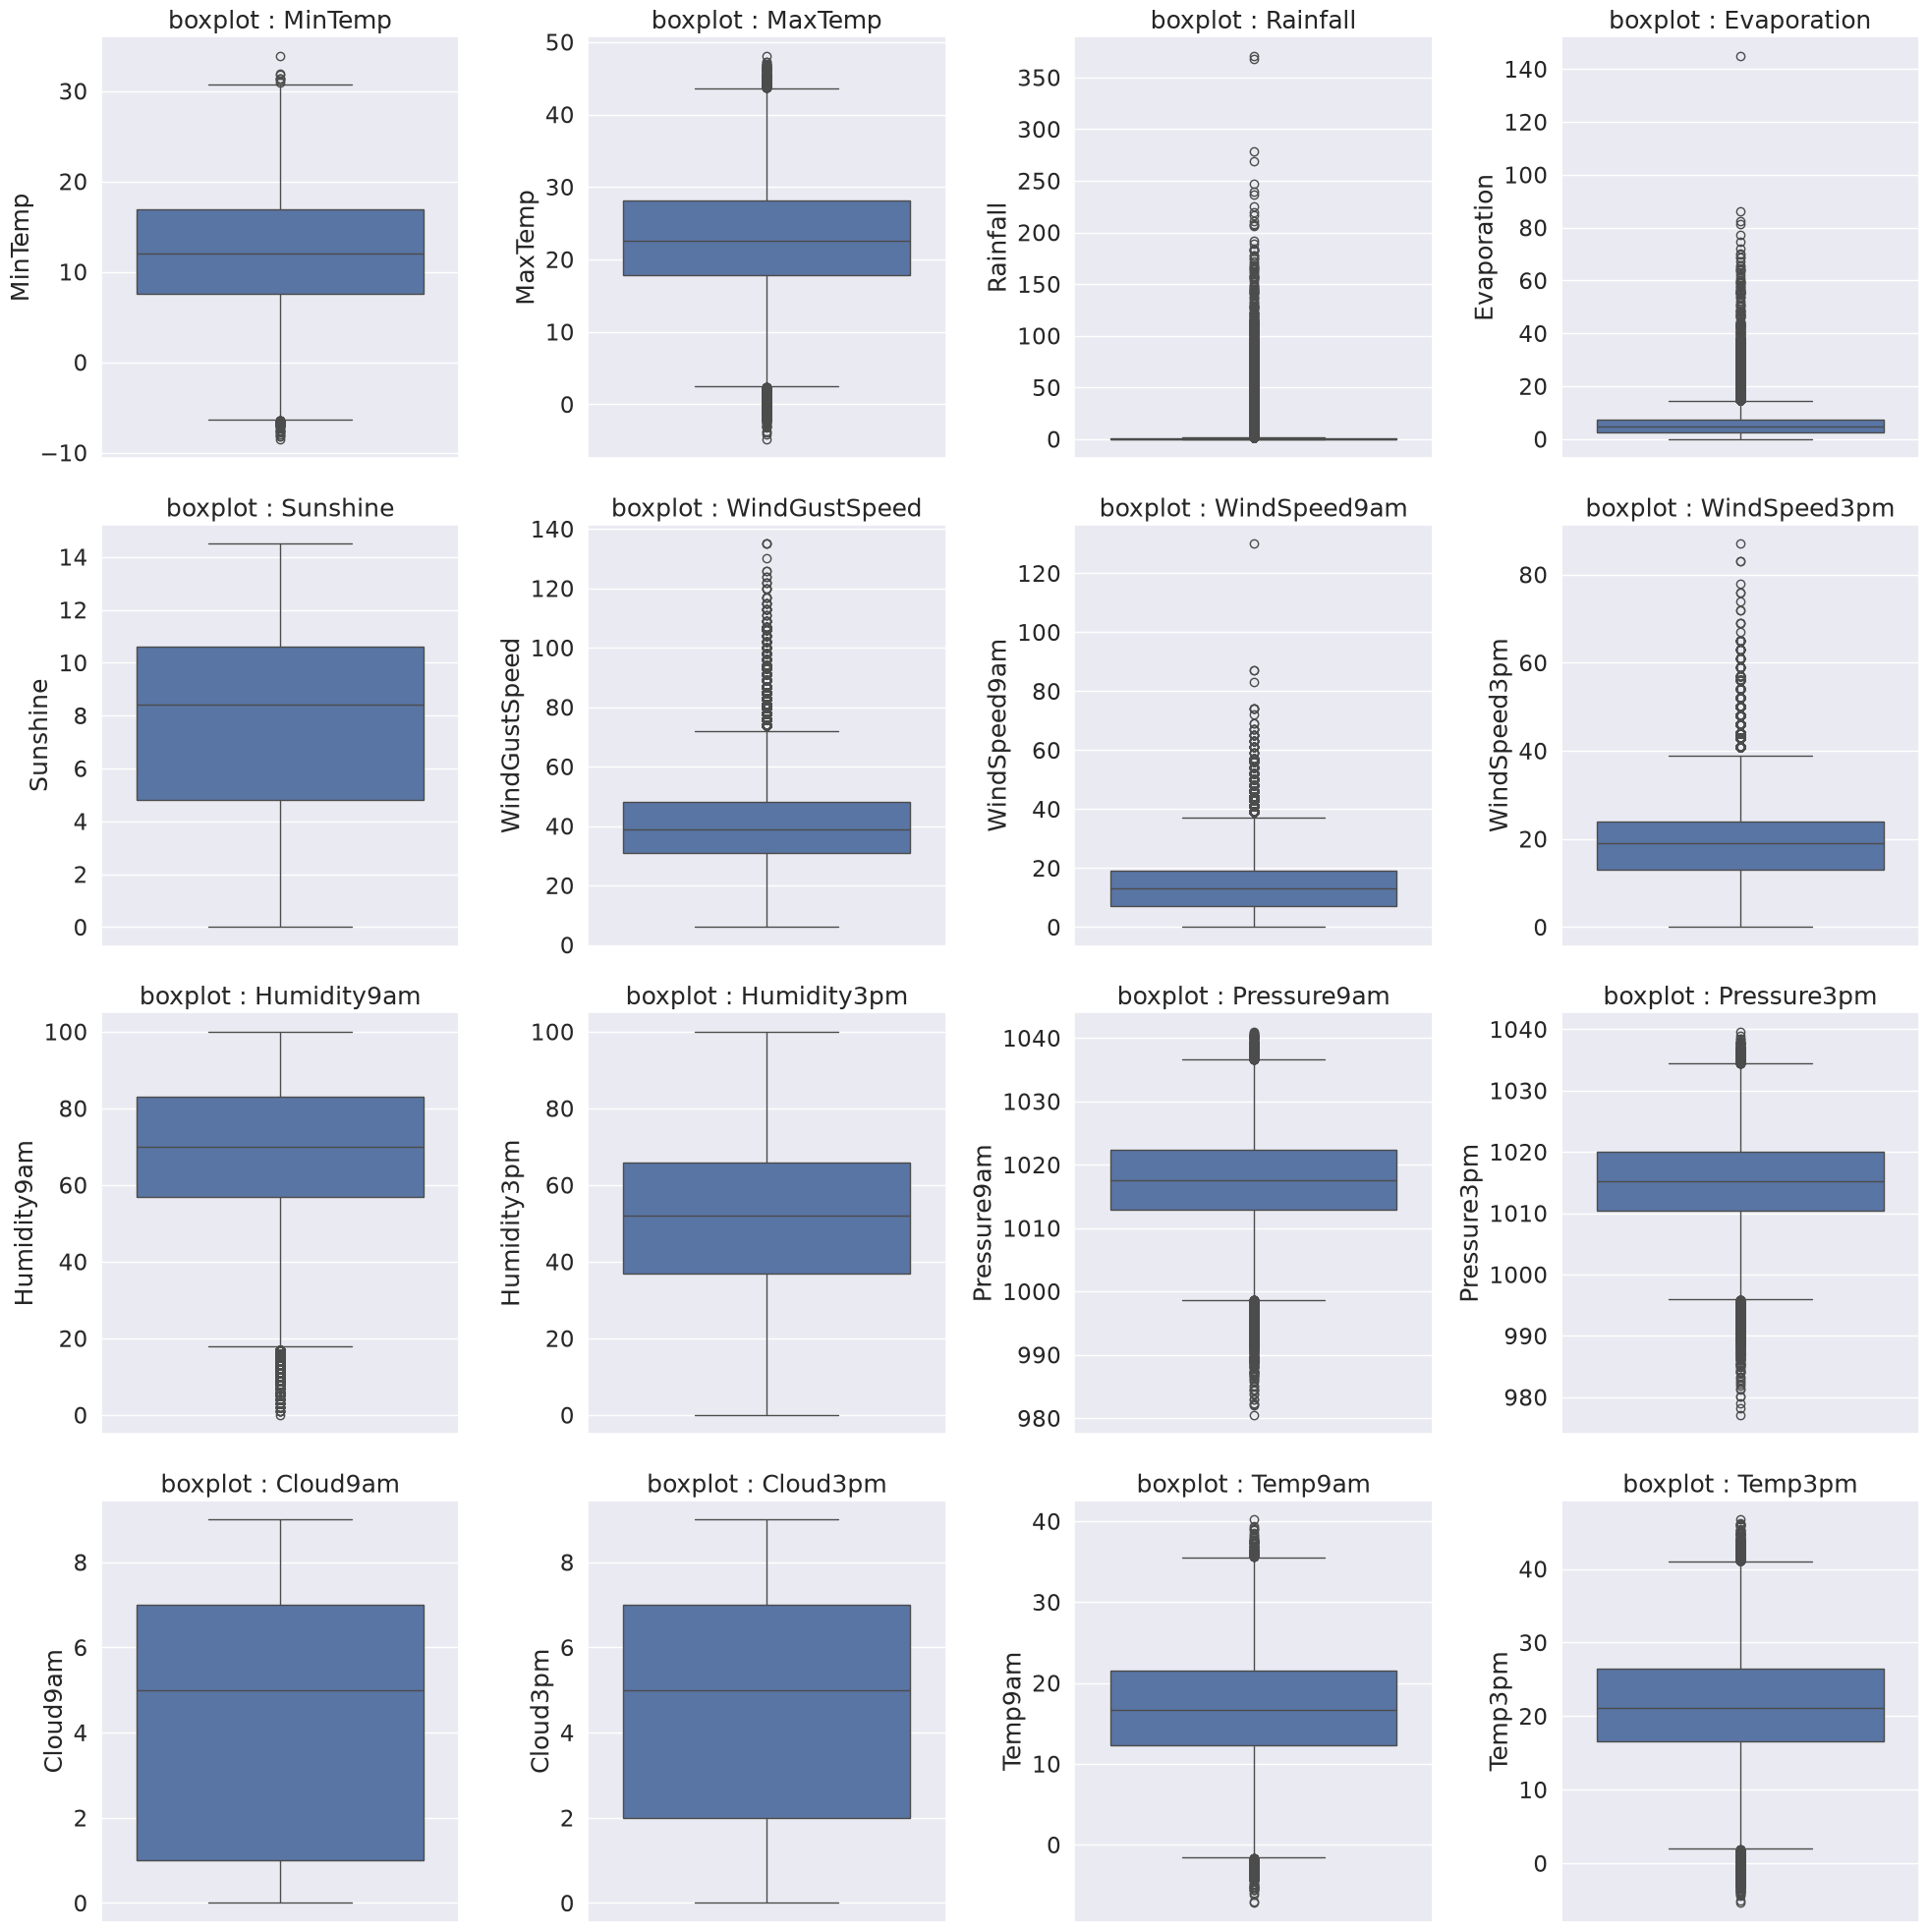

In [ ]:
# [문제] 4x4 fig로 각 fearture들 데이터 분포, 이상치 확인

nrows, ncols = 4, 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols)
fig.set_size_inches(20,20)

axs = axs.flatten()  # axs 2D -> 1D 
for i, col in enumerate(num_cols):
  ax = sns.boxplot(data=df, y=col, ax=axs[i])
  ax.set_title("boxplot : " + col)

plt.tight_layout()

In [89]:
df['Rainfall'].max()

np.float64(371.0)

In [90]:
df['Rainfall'].mean()

np.float64(2.360918149916666)

In [91]:
df['Rainfall'].median()

np.float64(0.0)

In [92]:
df.shape

(145460, 23)

### Rainfall 컬럼에서 0이 아닌것만 필터링 

In [93]:
filtered_rainfall = df.query('Rainfall != 0.0').copy()

In [94]:
filtered_rainfall.shape

(54380, 23)

In [95]:
filtered_rainfall.index

Index([     0,      4,      5,      9,     11,     12,     13,     15,     17,
           18,
       ...
       145323, 145324, 145325, 145326, 145336, 145391, 145392, 145393, 145394,
       145429],
      dtype='int64', length=54380)

In [96]:
filtered_rainfall.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No


### 이상치 확인하는 함수

In [97]:
df = pd.read_csv('datas_ml/weatherAUS.csv')
print(df.shape)

(145460, 23)


In [ ]:
# 이상치 확인하는 함수
def get_outlier_indices(data, columns):
    outlier_indices = []   # 이상치에 해당하는 행의 목록 리스트
    for column in columns:
        Q1 = data[column].quantile(0.25) # 25%분위수(1Q)
        Q3 = data[column].quantile(0.75) # 75%분위수(3Q)
        IQR = Q3 - Q1
        # 최소값
        min_value = Q1 - 1.5*IQR
        # 최대값
        max_value = Q3 + 1.5*IQR

        # 이상치의 인덱스를 추출하기 위한 필터
        filter = ((data[column] < min_value) | (data[column] > max_value))  
        # 필터를 적용해 이상치를 추출
        outlier_data = data[column][filter]
        # 해당 컬럼의 이상치 데이터의 index
        outlier_index = outlier_data.index
        # index 리스트를 outlier_index에 추가함
        outlier_indices.extend(outlier_index)

    # 처리한 모든 컬럼의 이상치의 인덱스를 리턴함
    return outlier_indices

In [99]:
print('dataframe before removing outlier (Rainfall column) :', df.shape)
delete_indices = get_outlier_indices(filtered_rainfall, ['Rainfall'])
# print(delete_indices)

dataframe before removing outlier (Rainfall column) : (145460, 23)


In [ ]:
# reset_idex(drop=True) : df의 index를 reset할 때, 원래 인덱스가 컬럼으로 추가되지 않도록 삭제함
df = df.drop(delete_indices, axis=0).reset_index(drop=True)
print('dataframe after removing outlier (Rainfall column) :', df.shape)

dataframe after removing outlier (Rainfall column) : (140240, 23)


In [101]:
print('dataframe before removing outlier (etc) :', df.shape)
delete_indices = get_outlier_indices(df, ['Humidity9am','Evaporation', 'WindGustSpeed', 'Pressure9am', 'Pressure3pm'])


dataframe before removing outlier (etc) : (140240, 23)


In [102]:
df = df.drop(delete_indices, axis=0).reset_index(drop=True)
print('dataframe after removing outlier (etc) :', df.shape)

dataframe after removing outlier (etc) : (133529, 23)


### 이상치 제거후 boxplot으로 확인

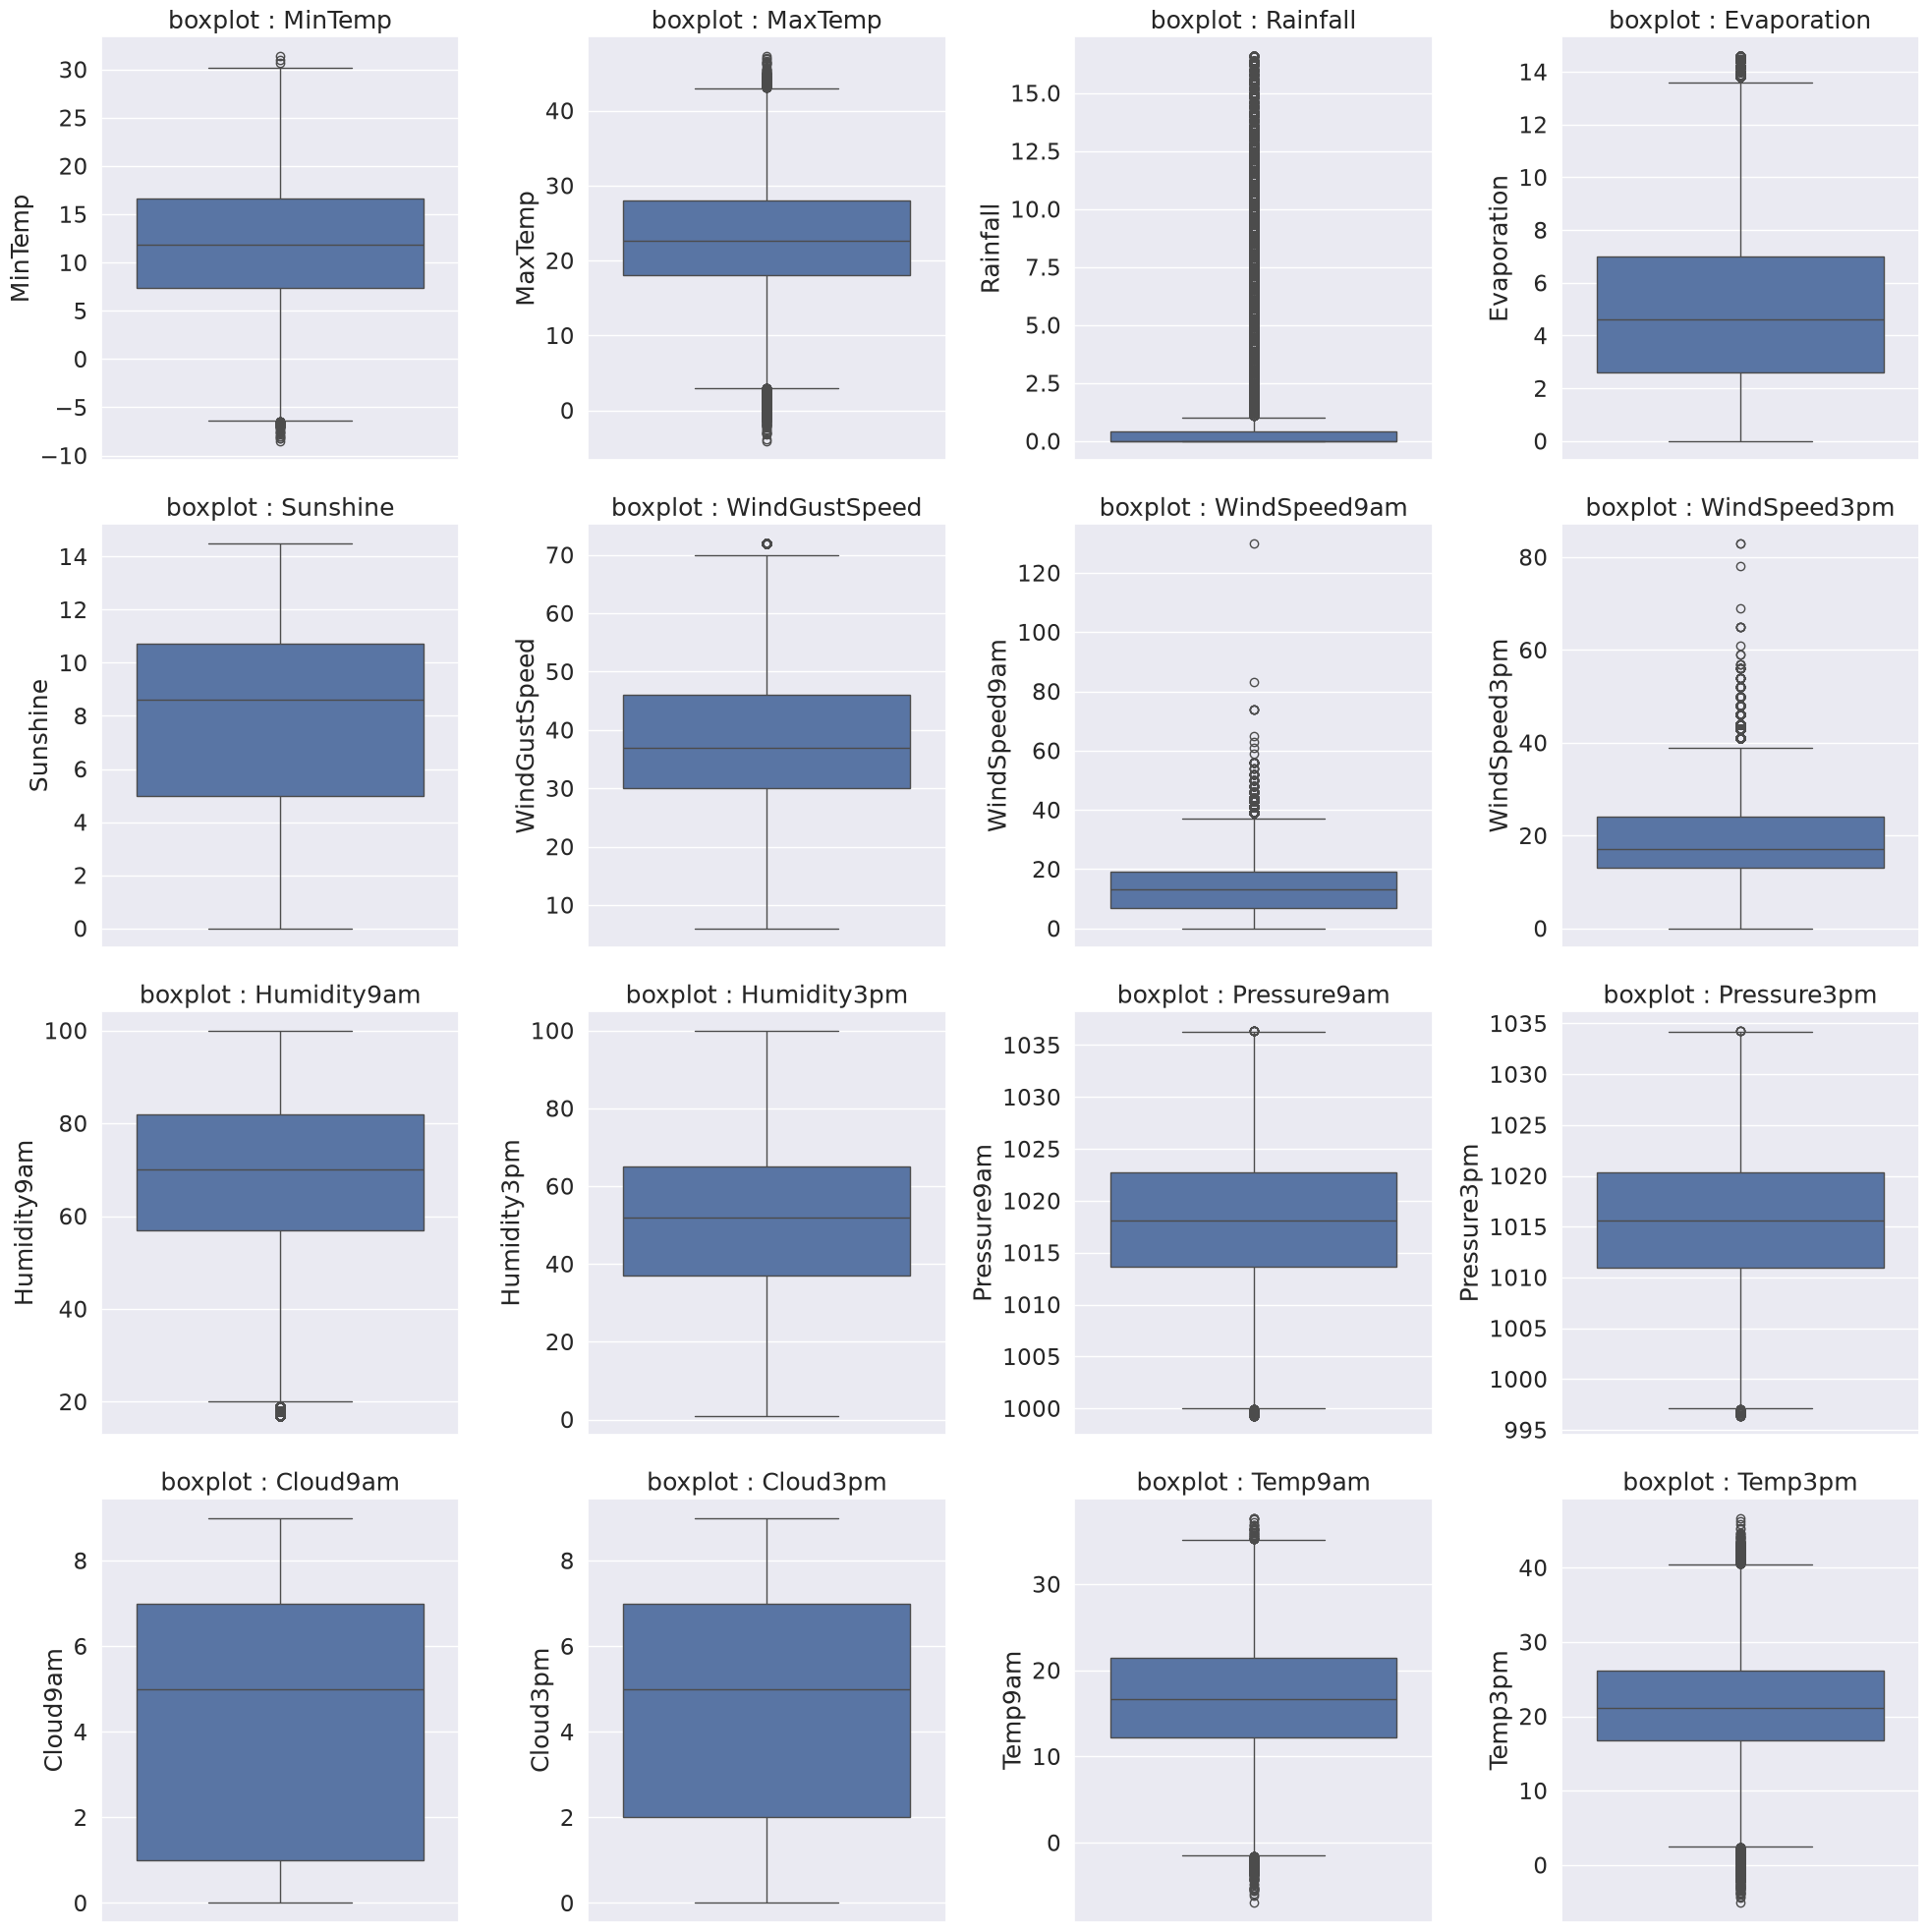

In [103]:
nrows, ncols = 4, 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols)
fig.set_size_inches(20,20) 

axs = axs.flatten()  # axs 2D -> 1D
for i, col in enumerate(num_cols): 
  ax = sns.boxplot(data=df, y=col, ax=axs[i]) 
  ax.set_title("boxplot : " + col)

plt.tight_layout()

- 문제 : 위에서 이상치 제거한 컬럼만 boxplot으로 시각화하기

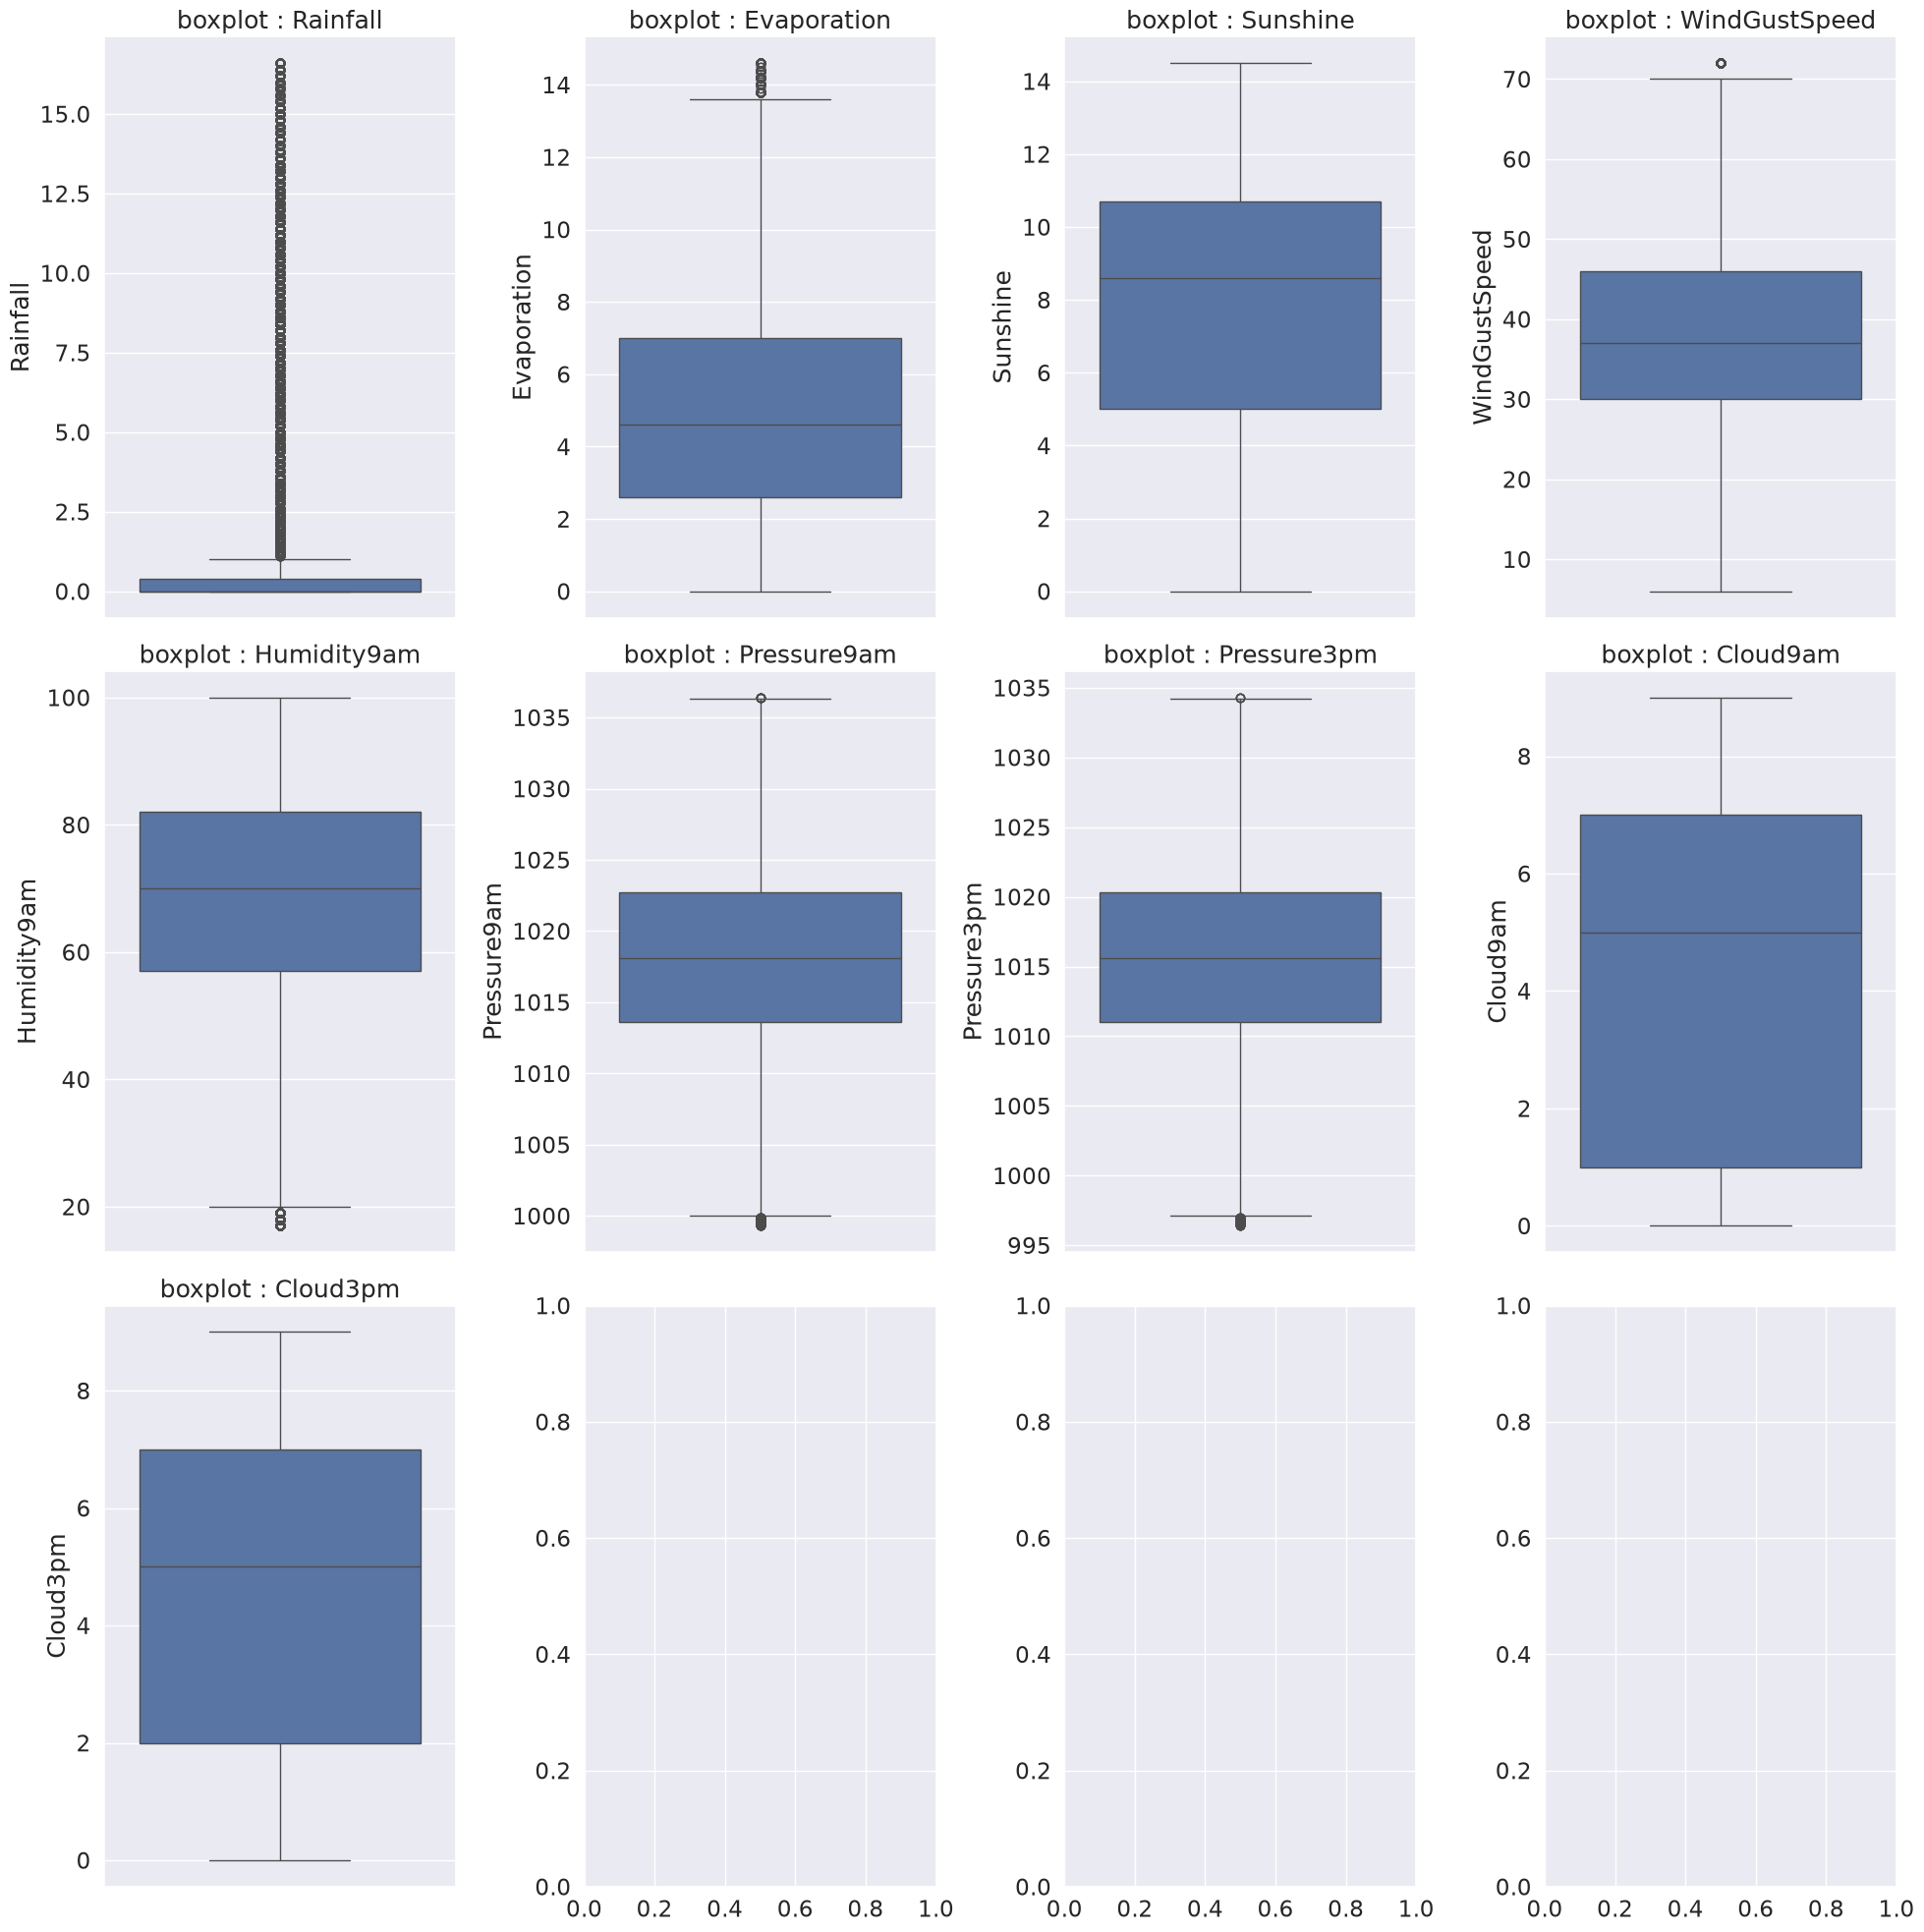

In [104]:
# 이상치 제거한 컬럼만 시각화
outlier_remove_cols = ['Rainfall','Evaporation', 'Sunshine', 'WindGustSpeed','Humidity9am', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm']

# 4x4 fig로 각 fearture들 데이터 분포, 이상치 확인

nrows, ncols = 3, 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols)
fig.set_size_inches(20,20) 

axs = axs.flatten()  # axs 2D -> 1D
for i, col in enumerate(outlier_remove_cols):
  ax = sns.boxplot(data=df, y=col, ax=axs[i])
  ax.set_title("boxplot : " + col)

plt.tight_layout()

## 결측치(null값) 확인 및 처리하기

In [105]:
df.isnull().mean().sort_values()

Date             0.000000
Location         0.000000
MaxTemp          0.008897
MinTemp          0.010560
Temp9am          0.012267
WindSpeed9am     0.012611
Humidity9am      0.018400
WindSpeed3pm     0.021666
RainTomorrow     0.022744
RainToday        0.023478
Rainfall         0.023478
Temp3pm          0.025058
WindDir3pm       0.029829
Humidity3pm      0.031282
WindGustSpeed    0.072786
WindGustDir      0.073220
WindDir9am       0.075931
Pressure3pm      0.105647
Pressure9am      0.105962
Cloud9am         0.389653
Cloud3pm         0.413805
Evaporation      0.437014
Sunshine         0.483640
dtype: float64

### categorical / numerical column 확인하기

In [106]:
print(cat_cols)

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


In [107]:
print(num_cols)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')


### 결측치 개수 확인하기

In [108]:
df[cat_cols].isnull().mean().sort_values()

Date            0.000000
Location        0.000000
RainTomorrow    0.022744
RainToday       0.023478
WindDir3pm      0.029829
WindGustDir     0.073220
WindDir9am      0.075931
dtype: float64

In [109]:
df[num_cols].isnull().mean().sort_values()

MaxTemp          0.008897
MinTemp          0.010560
Temp9am          0.012267
WindSpeed9am     0.012611
Humidity9am      0.018400
WindSpeed3pm     0.021666
Rainfall         0.023478
Temp3pm          0.025058
Humidity3pm      0.031282
WindGustSpeed    0.072786
Pressure3pm      0.105647
Pressure9am      0.105962
Cloud9am         0.389653
Cloud3pm         0.413805
Evaporation      0.437014
Sunshine         0.483640
dtype: float64

In [110]:
for col in num_cols:
    if df[col].isnull().mean()>0:
        col_median=df[col].median()
        df[col] = df[col].fillna(col_median)

In [111]:
for col in num_cols:
    if df[col].isnull().mean()>0:
        print(col, (df[col].isnull().mean()))

In [112]:
df['WindGustDir'] = df['WindGustDir'].fillna(df['WindGustDir'].mode()[0])
df['WindDir9am'] = df['WindDir9am'].fillna(df['WindDir9am'].mode()[0])
df['WindDir3pm'] = df['WindDir3pm'].fillna(df['WindDir3pm'].mode()[0])
df['RainToday'] = df['RainToday'].fillna(df['RainToday'].mode()[0])

In [113]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,4.6,8.6,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,4.6,8.6,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,4.6,8.6,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,4.6,8.6,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,4.6,8.6,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [114]:
df = df.drop(['Date'], axis=1)

In [115]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.6,8.6,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,4.6,8.6,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,4.6,8.6,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,4.6,8.6,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,4.6,8.6,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [116]:
df.isnull().mean().sort_values()

Location         0.000000
MinTemp          0.000000
MaxTemp          0.000000
Rainfall         0.000000
Evaporation      0.000000
Sunshine         0.000000
WindGustDir      0.000000
WindGustSpeed    0.000000
WindDir9am       0.000000
WindDir3pm       0.000000
WindSpeed9am     0.000000
WindSpeed3pm     0.000000
Humidity9am      0.000000
Humidity3pm      0.000000
Pressure9am      0.000000
Pressure3pm      0.000000
Cloud9am         0.000000
Cloud3pm         0.000000
Temp9am          0.000000
Temp3pm          0.000000
RainToday        0.000000
RainTomorrow     0.022744
dtype: float64

### RainTomorrow가 null은 어떻게 처리해야할까?

In [117]:
df.shape

(133529, 22)

In [118]:
df = df.dropna(subset=['RainTomorrow'])
df['RainTomorrow']

0         No
1         No
2         No
3         No
4         No
          ..
133523    No
133524    No
133525    No
133526    No
133527    No
Name: RainTomorrow, Length: 130492, dtype: str

In [119]:
df.isnull().mean().sort_values()

Location         0.0
MinTemp          0.0
MaxTemp          0.0
Rainfall         0.0
Evaporation      0.0
Sunshine         0.0
WindGustDir      0.0
WindGustSpeed    0.0
WindDir9am       0.0
WindDir3pm       0.0
WindSpeed9am     0.0
WindSpeed3pm     0.0
Humidity9am      0.0
Humidity3pm      0.0
Pressure9am      0.0
Pressure3pm      0.0
Cloud9am         0.0
Cloud3pm         0.0
Temp9am          0.0
Temp3pm          0.0
RainToday        0.0
RainTomorrow     0.0
dtype: float64

In [120]:
df.shape

(130492, 22)

# Yes/No 값에 대한 변환

In [121]:
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

print(df['RainToday'].dtype, df['RainTomorrow'].dtype)

int64 int64


## categorical value에 one-hot encoding 적용하기

In [122]:
df = pd.get_dummies(df, columns = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'])

In [123]:
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.6,8.6,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.6,8.6,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.6,8.6,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.6,8.6,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,4.6,8.6,41.0,7.0,20.0,82.0,33.0,...,False,True,False,False,False,False,False,False,False,False


In [124]:
df.shape

(130492, 115)

# 트레이닝 데이터 준비

In [125]:
X = df.drop(['RainTomorrow'], axis=1)
y = df['RainTomorrow']

In [126]:
X.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.6,8.6,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.6,8.6,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.6,8.6,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.6,8.6,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,4.6,8.6,41.0,7.0,20.0,82.0,33.0,...,False,True,False,False,False,False,False,False,False,False


In [127]:
y[:5]

0    0
1    0
2    0
3    0
4    0
Name: RainTomorrow, dtype: int64

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2024)

# ML 학습, 테스트, 평가
- 내일 비가 올지 안올지 예측해보기
- 학습기 : Random Forest

## ML 학습

In [129]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
score = accuracy_score(y_test, y_pred)
# baseline - 랜덤 포레스트(Random Forest) Accuracy : 0.8533352086922887
print('랜덤 포레스트(Random Forest) Accuracy (After removing Outlier):', score)

랜덤 포레스트(Random Forest) Accuracy (After removing Outlier): 0.8579255910188129


## ML 모델 평가

In [130]:
from sklearn.metrics import classification_report
# classification_report() 결과 출력
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92     20784
           1       0.77      0.43      0.55      5315

    accuracy                           0.86     26099
   macro avg       0.82      0.70      0.73     26099
weighted avg       0.85      0.86      0.84     26099



### 문제 XGBoost로 모델 만들고 평가하기

In [131]:
from xgboost import XGBClassifier
# xgb_clf = XGBClassifier()
xgb_clf = XGBClassifier()

xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('accuracy :', accuracy)

accuracy : 0.8607609486953524


In [132]:
# 레포트
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.92     20784
           1       0.73      0.50      0.59      5315

    accuracy                           0.86     26099
   macro avg       0.81      0.73      0.76     26099
weighted avg       0.85      0.86      0.85     26099



## LGBM 분류기

In [133]:
from lightgbm import LGBMClassifier
lgbm_clf = LGBMClassifier()
lgbm_clf.fit(X_train, y_train)
y_pred = lgbm_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('accuracy :', accuracy)

[LightGBM] [Info] Number of positive: 21257, number of negative: 83136
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002012 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2414
[LightGBM] [Info] Number of data points in the train set: 104393, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203625 -> initscore=-1.363792
[LightGBM] [Info] Start training from score -1.363792
accuracy : 0.8594965324341929


In [134]:
# 레포트
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92     20784
           1       0.74      0.48      0.58      5315

    accuracy                           0.86     26099
   macro avg       0.81      0.72      0.75     26099
weighted avg       0.85      0.86      0.85     26099

